In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import fsolve
%run IPR.ipynb
%run VLP.ipynb

In [11]:
Qo_array_VLP = Qo_array_IPR[1:]
Pwf_array_VLP= Poettmann_and_Carpenter_Method(Pwh_VLP, T, d, API, GLR, Bw, fo, fw, Yg, Yo, Yw, Qo_array_VLP, depth)

In [12]:
# Interpolation
from scipy.interpolate import splrep, splev
Pwf_predictator_VLP = splrep(Qo_array_VLP, Pwf_array_VLP, k=3, s=9)
Pwf_predicted_VLP = splev(Qo_array_VLP, Pwf_predictator_VLP )

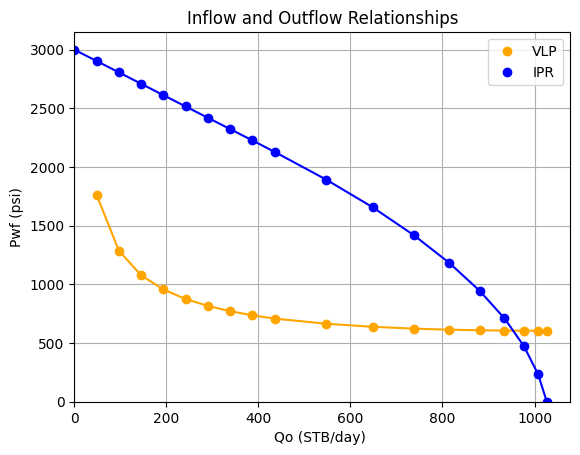

In [13]:
# Create the plot
plt.plot( Qo_array_VLP, Pwf_predicted_VLP, 'o', label='VLP', color='orange')
plt.plot(Qo_array_VLP, Pwf_predicted_VLP, '-', color='orange')
plt.plot( Qo_array_IPR, Pwf_array_IPR, 'o', label='IPR', color='blue')
plt.plot(Qo_array_IPR, Pwf_predicted_IPR, '-', color='blue')

# Set the y-axis limits to start at the bottom of the well till top (inverted)
plt.ylim(0, )
plt.xlim(0, )

# Customize labels and title
plt.xlabel('Qo (STB/day) ')
plt.ylabel('Pwf (psi)')
plt.title('Inflow and Outflow Relationships')

# Add a horizontal line at y=0 for better visualization of mirrored effect (optional)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

# Adjust legend placement (optional)
plt.legend(loc='upper right')

# Display the plot
plt.grid(True)
plt.show()

In [14]:
def find_intersection(Qo, Pwf_predictator_VLP_in, Pwf_predictator_IPR_in):
    Pwf_VLP = splev(Qo, Pwf_predictator_VLP_in)
    Pwf_IPR = splev(Qo, Pwf_predictator_IPR_in)
    return Pwf_VLP - Pwf_IPR

# Example usage with different pairs of curves
def calculate_intersection(Pwf_predictator_VLP_in, Pwf_predictator_IPR_in, initial_guess=500.0):
    Qo_intersection = fsolve(find_intersection, initial_guess, args=(Pwf_predictator_VLP_in, Pwf_predictator_IPR_in))
    Pwf_intersection = splev(Qo_intersection, Pwf_predictator_VLP_in)
    return Qo_intersection[0], Pwf_intersection[0]

In [15]:
print(f"Operating Condition: ( Qo (STB/day), Pwf (psi) ) = ({calculate_intersection(Pwf_predictator_VLP, Pwf_predictator_IPR, initial_guess=500.0)[0]:.2f}, {calculate_intersection(Pwf_predictator_VLP, Pwf_predictator_IPR, initial_guess=500.0)[1]:.2f})")

Operating Condition: ( Qo (STB/day), Pwf (psi) ) = (954.72, 605.95)
